# Deep Q-Trading: a DQN experiment on historical BTC/USD

This notebook trains a deep Q-network on daily observations from 2015–2020 and evaluates a frozen policy on 2021–2023 data. The download endpoint is fixed to 2024-01-01 (exclusive), and a local CSV cache preserves the fetched bars.

The state contains 30 observations and nine features: OHLC, volume, RSI and three MACD series. Scaler parameters are fitted only to the training period. This finite observation window does not establish the Markov property or stationarity.

Actions are `Sell=0` (short exposure) and `Buy=1` (long exposure). An action chosen from prices through time t determines exposure to the t-to-t+1 return. The toy reward is the log of the wealth multiplier $1 + a_t(P_{t+1}/P_t - 1)$, where exposure $a_t$ is -1 or +1, less multiplicative fees. The model charges 10 basis points on initial entry, position switches and final liquidation. It omits spread, slippage, financing and the cost of daily exposure rebalancing.

Replay sampling reduces dependence between training batches; a target network stabilizes Bellman updates. Neither mechanism guarantees profitable generalization. The final comparison uses the same tradable dates and entry/exit fees for buy-and-hold and reports drawdown alongside return. It is an illustrative backtest on one split and seed, not evidence of alpha.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym
import gym_anytrading
from gym_anytrading.envs import StocksEnv, Actions, Positions

# Configuration & Reproducibility
SEED = 2024
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# Hardware Acceleration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"System Initialized.")
print(f"   Device: {DEVICE}")
print(f"   Seed: {SEED}")
print(f"   Gym-Anytrading Loaded. Action Space: {Actions._member_names_}")

System Initialized.
   Device: cpu
   Seed: 2024
   Gym-Anytrading Loaded. Action Space: ['Sell', 'Buy']


## 2. Data Acquisition and Feature Engineering

A reinforcement learning agent is only as good as its perception of the environment. Raw price data (Open, High, Low, Close) is often insufficient for training stable agents because absolute prices are **non-stationary** (BTC at \$1,000 behaves differently than BTC at \$60,000).

To solve this, we perform **Feature Engineering** to derive additional signals (without guaranteeing stationarity) (indicators) that represent market *state* (momentum, volatility, trend) rather than market *value*.

**The Pipeline:**
1.  **Data Source:** We extract daily BTC-USD data from Yahoo Finance (2015–2023, with an exclusive 2024-01-01 endpoint).
2.  **Indicators (The Sensors):** We augment the state space $\mathcal{S}$ with:
    * **RSI (Relative Strength Index):** Measures overbought/oversold conditions (Momentum).
    * **MACD (Moving Average Convergence Divergence):** Measures trend direction and strength.
3.  **The "Time-Travel" Split:**
    We strictly separate the dataset by time to prevent **Look-Ahead Bias**.
    * **Training Set (2015-2020):** The history the agent studies.
    * **Testing Set (2021+):** The future the agent must navigate blindly.


Data Status:
   Total Samples: 3254
   Training Set:  2159 days (Ends 2020-12-31)
   Testing Set:   1095 days (2021-01-01 to 2023-12-31)


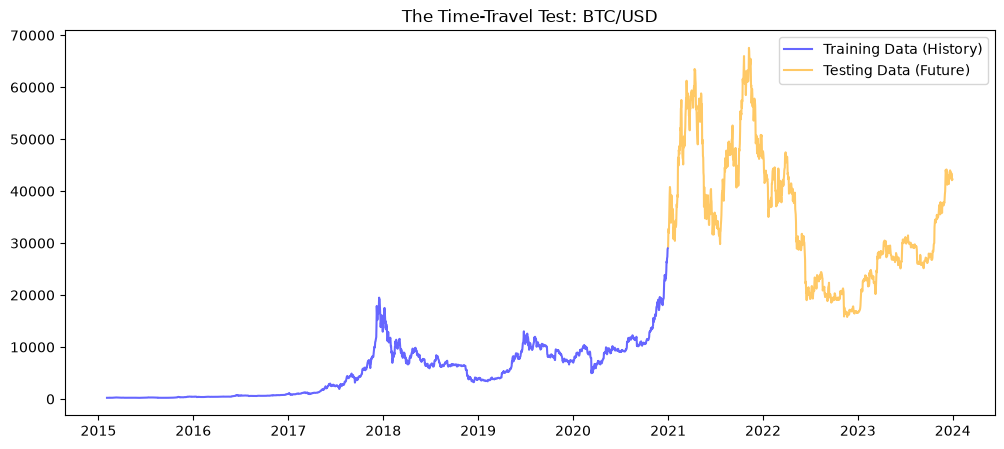

In [2]:
# 1. Fetch Real Market Data
# We use Yahoo Finance to get BTC-USD daily data from 2015 to Present
import yfinance as yf
from pathlib import Path

def get_crypto_data(symbol="BTC-USD", start="2015-01-01", end="2024-01-01"):
    print(f"Downloading {symbol} data...")
    cache = Path("data") / f"{symbol}_{start}_{end}.csv"
    if cache.exists():
        return pd.read_csv(cache, index_col=0, parse_dates=True)
    df = yf.download(symbol, start=start, end=end, progress=False, auto_adjust=True)
    if df.empty:
        raise ValueError("No market data returned; inspect the source or supply the documented cache.")
    
    # Cleaning: YFinance sometimes returns MultiIndex columns, we flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].sort_index()
    if df.index.has_duplicates or df.isna().any().any() or (df['Close'] <= 0).any():
        raise ValueError("Market data must have unique dates, complete values and positive prices.")
    cache.parent.mkdir(exist_ok=True)
    df.to_csv(cache)
    return df

# 2. Feature Engineering (The "Sensors")
# We add technical indicators so the agent can "see" momentum and volatility.
def add_indicators(df):
    df = df.copy()
    # RSI (Relative Strength Index): Detects Overbought/Oversold
    df['RSI'] = ta.rsi(df['Close'], length=14)
    
    # MACD (Moving Average Convergence Divergence): Detects Trend changes
    # MACD returns 3 columns: MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df = pd.concat([df, macd], axis=1)
    
    # Drop NaN values generated by indicators (first ~30 rows)
    df.dropna(inplace=True)
    return df

# --- EXECUTION ---
df_raw = get_crypto_data("BTC-USD")
df_featured = add_indicators(df_raw)

# 3. The Time-Travel Split
# Training: 2015 -> 2020 (The Agent learns here)
# Testing:  2021 -> 2023 (The Agent is tested here on unseen data)
split_date = "2021-01-01"

train_df = df_featured[df_featured.index < split_date]
test_df = df_featured[df_featured.index >= split_date]

print(f"\nData Status:")
print(f"   Total Samples: {len(df_featured)}")
print(f"   Training Set:  {len(train_df)} days (Ends {train_df.index[-1].date()})")
print(f"   Testing Set:   {len(test_df)} days ({test_df.index[0].date()} to {test_df.index[-1].date()})")

# Visualization of the Challenge
plt.figure(figsize=(12, 5))
plt.plot(train_df['Close'], label='Training Data (History)', color='blue', alpha=0.6)
plt.plot(test_df['Close'], label='Testing Data (Future)', color='orange', alpha=0.6)
plt.title("The Time-Travel Test: BTC/USD")
plt.legend()
plt.show()

## 3. Custom environment

`CryptoEnv` extends StocksEnv with a consistent log-return reward and wealth accounting. It uses all nine available features and a 30-day lookback, giving observation shape `(30, 9)`. Only observations are standardized, with training-only parameters; reward prices remain in original units. Price and feature slices use the same frame bounds.

The held-out environment starts after its 30-day lookback. Its first trade is therefore not on January 1, 2021; the exact comparison dates are printed below. The renderer marks the resulting positions by tick.


In [3]:
class CryptoEnv(StocksEnv):
    def __init__(self, df, window_size, frame_bound, feature_scaler):
        self.feature_scaler = feature_scaler
        # Prices stay in original units; only observations are scaled.
        super().__init__(df, window_size, frame_bound)
        # A fixed 10 bp cost per transaction side makes the training reward and
        # the reported strategy return use the same economic definition.
        self.trade_fee_percent = 0.001

    def _is_trade(self, action):
        return ((action == Actions.Buy.value and self._position == Positions.Short) or
                (action == Actions.Sell.value and self._position == Positions.Long))

    def _net_log_return(self, action):
        # The action chosen from the previous close is the exposure for this return.
        if action not in (Actions.Sell.value, Actions.Buy.value):
            raise ValueError("Action must be Sell (0) or Buy (1).")
        previous_price = self.prices[self._current_tick - 1]
        current_price = self.prices[self._current_tick]
        simple_return = current_price / previous_price - 1.0
        exposure = 1.0 if action == Actions.Buy.value else -1.0
        gross_return = 1.0 + exposure * simple_return
        if gross_return <= 0:
            raise ValueError("The short exposure is bankrupt; log return is undefined.")
        first_entry = self._current_tick == self._start_tick + 1
        costs = int(first_entry) + 2 * int(not first_entry and self._is_trade(action))
        costs += int(self._current_tick == self._end_tick)
        gross_return *= (1.0 - self.trade_fee_percent) ** costs
        return np.log(gross_return)

    def _calculate_reward(self, action):
        # Log returns add over time and map directly to cumulative wealth.
        return self._net_log_return(action)

    def _update_profit(self, action):
        self._total_profit *= np.exp(self._net_log_return(action))
        
    def _process_data(self):
        """
        This method is called internally by Gym to convert the raw DataFrame
        into the 'State' (Observation) that the Agent sees.
        """
        # We select the start and end indices based on the frame_bound (Train vs Test)
        start = self.frame_bound[0] - self.window_size
        end = self.frame_bound[1]
        
        # We extract the prices for the Reward Function
        prices = self.df.loc[:, 'Close'].to_numpy(dtype=float)[start:end]
        
        # We extract the features for the Neural Network Input
        # Signal Features: Close, Volume, RSI, MACD... (All columns)
        if start < 0 or end > len(self.df) or end - start <= self.window_size + 1:
            raise ValueError("frame_bound must contain the lookback and at least two return steps.")
        if not np.isfinite(prices).all() or (prices <= 0).any():
            raise ValueError("Prices must be finite and positive.")
        signal_features = self.feature_scaler.transform(self.df.iloc[start:end]).astype(np.float32)
        if not np.isfinite(signal_features).all():
            raise ValueError("Observations must be finite.")
        
        return prices, signal_features

# --- EXECUTION ---

# Configuration
WINDOW_SIZE = 30  # Agent sees the last 30 days
# Frame Bound: (Start_Index, End_Index)
# We start at WINDOW_SIZE because we need 30 days of history for the first state

from sklearn.preprocessing import StandardScaler
feature_scaler = StandardScaler().fit(train_df)

# 1. Create Training Environment
env_train = CryptoEnv(df=train_df, window_size=WINDOW_SIZE, frame_bound=(WINDOW_SIZE, len(train_df)), feature_scaler=feature_scaler)

# 2. Create Testing Environment
env_test = CryptoEnv(df=test_df, window_size=WINDOW_SIZE, frame_bound=(WINDOW_SIZE, len(test_df)), feature_scaler=feature_scaler)

print(f"Environment Initialized.")
print(f"   Observation Shape: {env_train.shape} (Days, Features)")
print(f"   Sample State:\n{env_train.reset()}")

Environment Initialized.
   Observation Shape: (30, 9) (Days, Features)
   Sample State:
(array([[-1.0370340e+00, -1.0332751e+00, -1.0406305e+00, -1.0343279e+00,
        -7.3733819e-01, -7.3525363e-01, -1.9937424e-01, -3.3325747e-02,
        -2.0488399e-01],
       [-1.0370020e+00, -1.0313890e+00, -1.0419977e+00, -1.0363415e+00,
        -7.3764354e-01, -9.5195735e-01, -2.0095083e-01, -3.8168699e-02,
        -2.0515694e-01],
       [-1.0392344e+00, -1.0331839e+00, -1.0416752e+00, -1.0352761e+00,
        -7.3749983e-01, -7.9487014e-01, -2.0086196e-01, -3.7166256e-02,
        -2.0535614e-01],
       [-1.0380478e+00, -1.0332265e+00, -1.0403107e+00, -1.0341417e+00,
        -7.3771179e-01, -6.2885523e-01, -1.9940117e-01, -3.2347042e-02,
        -2.0520091e-01],
       [-1.0369961e+00, -1.0334003e+00, -1.0406382e+00, -1.0350392e+00,
        -7.3804569e-01, -7.3988891e-01, -1.9889219e-01, -3.1278793e-02,
        -2.0496711e-01],
       [-1.0378907e+00, -1.0345023e+00, -1.0415068e+00, -1.035721

## 4. The Agent's Brain: Deep Q-Network (DQN) Architecture

We now define the Neural Network that will serve as the agent's policy.

In the previous Genetic Algorithm project, the network mapped Inputs $\to$ Actions directly. In **Deep Q-Learning**, the network maps Inputs $\to$ **Q-Values**.


* **Input:** The state matrix of shape `(30, 9)`. To feed this into a standard Feed-Forward Network (MLP), we **flatten** it into a single vector of size $30 \times 9 = 270$.
* **Hidden Layers:** We use two dense layers of 128 neurons with **ReLU** activation to capture non-linear market patterns.
* **Output:** A vector of size 2: $[Q(s, \text{Short}), Q(s, \text{Long})]$. The agent will choose the action with the highest value.

**Why Q-Values?**
The network is not predicting the *price*. It is predicting the **Expected Future Reward** of taking a specific action in the current state.
$$Q(s, a) \approx r + \gamma \max Q(s', a')$$

In [4]:
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()
        
        # Calculate the size of the flattened input vector
        # Input shape is (Window_Size, Features) -> e.g., (30, 9)
        self.input_dim = input_shape[0] * input_shape[1]
        
        # The Network Architecture (MLP)
        self.net = nn.Sequential(
            nn.Flatten(), # Flattens (Batch, 30, 9) -> (Batch, 270)
            
            # Layer 1: Feature Extraction
            nn.Linear(self.input_dim, 128),
            nn.ReLU(),
            
            # Layer 2: Pattern Recognition
            nn.Linear(128, 128),
            nn.ReLU(),
            
            # Layer 3: Value Estimation (Q-Values)
            nn.Linear(128, n_actions) 
        )

    def forward(self, x):
        return self.net(x)

# --- EXECUTION ---
# Initialize the model to verify dimensions
input_shape = env_train.observation_space.shape # (30, 9)
n_actions = env_train.action_space.n # 2

# We create two networks:
# 1. Policy Net: The one that learns (updated every step)
# 2. Target Net: A stable copy used to calculate loss (updated every 10 episodes)
policy_net = DQN(input_shape, n_actions).to(DEVICE)
target_net = DQN(input_shape, n_actions).to(DEVICE)

# Copy weights to ensure they start identical
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Target net is never trained, only updated via copy

print(f"Brain Initialized.")
print(f"   Input Vector Size: {policy_net.input_dim} neurons")
print(f"   Architecture:\n{policy_net}")

Brain Initialized.
   Input Vector Size: 270 neurons
   Architecture:
DQN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=270, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)


## 5. The Memory Bank: Experience Replay Buffer

One of the main reasons Deep Q-Learning works (where previous methods failed) is the **Replay Buffer**.

**The Problem: Correlation & Forgetting**
In a financial market, data is highly correlated. If the price is rising today, it is statistically likely to be high tomorrow. If we train the network sequentially, it will overfit to the current trend (e.g., "Always Buy" during a bull run) and completely forget how to survive a crash. This is known as **Catastrophic Forgetting**.

**The Solution: Random Sampling**
Instead of training on the latest trade, we save every interaction in a large circular buffer (e.g., capacity 10,000).
When training, we draw a **random batch** (e.g., 64 trades) mixed from recent days and months ago. This breaks the temporal correlation and reduces short-range correlation between gradient samples; it does not ensure robustness to new regimes.

**Structure of a Memory:**
Each entry is a tuple: $(State_t, Action_t, Reward_t, State_{t+1}, Done)$

In [5]:
from collections import deque, namedtuple

# We define a structured object for a single memory
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward', 'done'))

class ReplayBuffer:
    def __init__(self, capacity):
        # deque is a linked list that automatically removes the oldest element when full
        self.memory = deque(maxlen=capacity)
        
    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))
        
    def sample(self, batch_size):
        """Randomly select a batch of memories"""
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)

# --- EXECUTION ---
# Create a buffer that can hold 10,000 trades
memory = ReplayBuffer(10000)

# Dummy test to verify it works
dummy_state = np.zeros((30, 9))
memory.push(dummy_state, 1, dummy_state, 0.5, False)

print(f"Memory Bank Initialized.")
print(f"   Capacity: {memory.memory.maxlen} experiences")
print(f"   Current Size: {len(memory)}")
print(f"   Sample Structure: {memory.memory[0]._fields}")

Memory Bank Initialized.
   Capacity: 10000 experiences
   Current Size: 1
   Sample Structure: ('state', 'action', 'next_state', 'reward', 'done')


## 6. The Agent: $\epsilon$-Greedy Policy & Bellman Optimization

We encapsulate the learning logic in a `DQNAgent` class. This class handles two critical processes:

### A. Action Selection ($\epsilon$-Greedy)
The agent faces the **Exploration-Exploitation Dilemma**.
* **Exploration:** Choosing a random action to discover new strategies.
* **Exploitation:** Choosing the action with the highest estimated Q-value to maximize reward.

We manage this with a probability $\epsilon$ (Epsilon):
$$a_t = \begin{cases} \text{Random Action} & \text{with prob } \epsilon \\ \arg\max Q(s_t, a; \theta) & \text{with prob } 1 - \epsilon \end{cases}$$
$\epsilon$ starts high (1.0) and decays over time to a floor of 0.05.

### B. The Learning Step (Optimization)
To train the network, we sample a batch from memory and apply the **Bellman Equation**:
$$\text{Target} = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$$

We calculate the **Huber Loss** (Smooth L1 Loss) between the current prediction $Q(s, a)$ and this Target, then perform Backpropagation to update the weights.

In [6]:
class DQNAgent:
    def __init__(self, policy_net, target_net, memory, optimizer):
        self.policy_net = policy_net
        self.target_net = target_net
        self.memory = memory
        self.optimizer = optimizer
        self.steps_done = 0
        
    def select_action(self, state, epsilon):
        """
        Selects an action using the Epsilon-Greedy strategy.
        """
        self.steps_done += 1
        
        # 1. Exploration: Random Action
        if random.random() < epsilon:
            return env_train.action_space.sample() # Random 0 or 1
            
        # 2. Exploitation: Use the Network
        else:
            with torch.no_grad():
                # Convert state to tensor and move to device
                # Shape: (1, 30, 9) -> Flattened internally by DQN
                # Use np.array to create the tensor efficiently
                state_tensor = torch.tensor(np.array(state), dtype=torch.float).unsqueeze(0).to(DEVICE)
                q_values = self.policy_net(state_tensor)
                
                # Return the index of the max Q-value
                return q_values.argmax().item()

    def optimize_model(self, batch_size, gamma=0.99):
        """
        The Core Learning Loop: Samples memory and updates weights.
        """
        if len(self.memory) < batch_size:
            return 0.0 # Not enough memory to train yet
        
        # 1. Sample a random batch
        transitions = self.memory.sample(batch_size)
        # Transpose the batch
        batch = Transition(*zip(*transitions))
        
        state_batch = torch.tensor(np.array(batch.state), dtype=torch.float).to(DEVICE)
        action_batch = torch.tensor(batch.action, dtype=torch.long).unsqueeze(1).to(DEVICE)
        reward_batch = torch.tensor(np.array(batch.reward), dtype=torch.float).unsqueeze(1).to(DEVICE)
        next_state_batch = torch.tensor(np.array(batch.next_state), dtype=torch.float).to(DEVICE)
        
        # Done mask
        # We process the boolean list in python then convert
        not_done_mask = torch.tensor([1.0 if not d else 0.0 for d in batch.done], dtype=torch.float).unsqueeze(1).to(DEVICE)

        # 2. Compute Q(s_t, a) - The agent's current prediction
        current_q_values = self.policy_net(state_batch).gather(1, action_batch)

        # 3. Compute V(s_{t+1}) - The Target Network's estimation
        next_q_values = self.target_net(next_state_batch).max(1)[0].unsqueeze(1).detach()

        # 4. Compute the Expected Q values (Bellman Equation)
        expected_q_values = reward_batch + (next_q_values * gamma * not_done_mask)

        # 5. Compute Loss
        loss = F.smooth_l1_loss(current_q_values, expected_q_values)

        # 6. Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
        return loss.item()

# Re-create the optimizer and agent with the new class definition
LEARNING_RATE = 0.0001
optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
agent = DQNAgent(policy_net, target_net, memory, optimizer)

print(f"Agent Online (v2 - Robust).")

Agent Online (v2 - Robust).


## 7. The Training Loop: In-Sample Optimization (2015-2020)

We now commence the training process over the **In-Sample** period (Training Set).

**The Routine (Per Episode):**
1.  **Reset:** The agent starts at the same beginning of the training timeline.
2.  **Step:** The agent observes the state $s_t$, picks an action $a_t$, and receives a reward $r_t$.
3.  **Learn:** The agent samples a batch from memory and updates its weights via Backpropagation.
4.  **Target Update:** Every $C$ episodes, we copy the weights from the Policy Net to the Target Net to stabilize the moving target.

**Epsilon Decay Schedule:**
We start with $\epsilon=1.0$ (100% Random Exploration) to fill the memory with diverse experiences. We decay this value exponentially toward $\epsilon=0.05$ (5% Randomness), forcing the agent to rely on its learned policy.

Starting Training on cpu...
   Memory Purged. Starting fresh.
   Episodes: 50
   Batch Size: 128


Episode 005/50 | Reward:    12.96 | Avg Loss: 0.00011 | Epsilon: 0.6081


Episode 010/50 | Reward:    29.13 | Avg Loss: 0.00003 | Epsilon: 0.3778


Episode 015/50 | Reward:    32.06 | Avg Loss: 0.00007 | Epsilon: 0.2426


Episode 020/50 | Reward:    37.80 | Avg Loss: 0.00003 | Epsilon: 0.1631


...

Episode 030/50 | Reward:    42.27 | Avg Loss: 0.00002 | Epsilon: 0.0890


Episode 035/50 | Reward:    43.08 | Avg Loss: 0.00002 | Epsilon: 0.0729


Episode 040/50 | Reward:    43.61 | Avg Loss: 0.00002 | Epsilon: 0.0635


Episode 045/50 | Reward:    45.09 | Avg Loss: 0.00002 | Epsilon: 0.0579


Episode 050/50 | Reward:    45.08 | Avg Loss: 0.00001 | Epsilon: 0.0546
Training Complete.


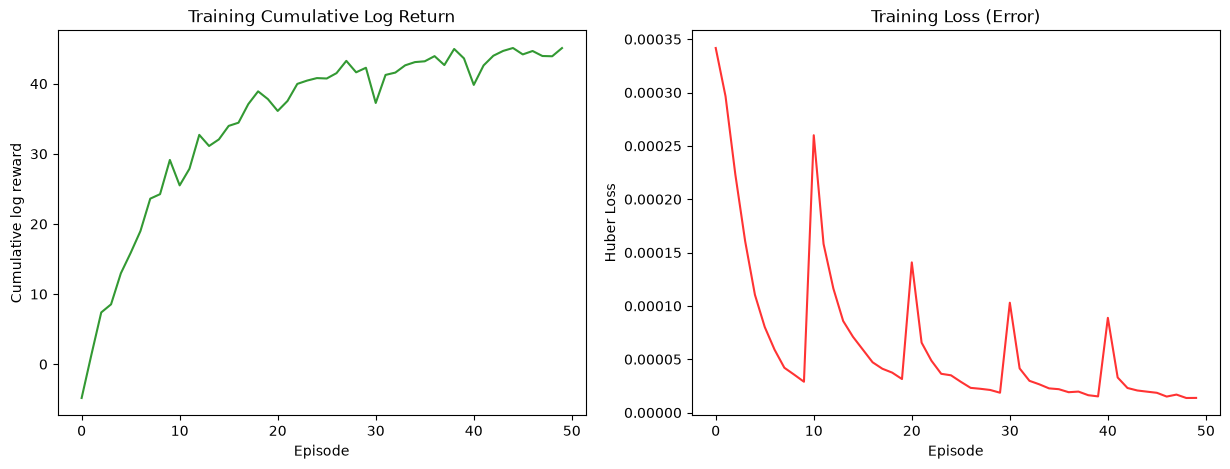

In [7]:
# Hyperparameters
NUM_EPISODES = 50       # Total passes through the environment
BATCH_SIZE = 128        # How many memories to train on per step
TARGET_UPDATE = 10      # Update Target Net every 10 episodes
GAMMA = 0.99            # Discount factor (Future rewards importance)

# Epsilon Decay (Exploration Schedule)
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 20000       # Controls how slow the decay is

# Logging
track_rewards = []
track_losses = []

print(f"Starting Training on {DEVICE}...")

# We clear the memory to remove any corrupted data from previous failed runs
agent.memory.memory.clear()
print(f"   Memory Purged. Starting fresh.")

print(f"   Episodes: {NUM_EPISODES}")
print(f"   Batch Size: {BATCH_SIZE}")

for i_episode in range(1, NUM_EPISODES + 1):
    # Initialize the environment and state
    state = env_train.reset(seed=SEED + i_episode)
    
    # Handle reset returning tuple in newer gym versions
    if isinstance(state, tuple):
        state = state[0]
        
    total_reward = 0
    total_loss = 0
    steps_in_episode = 0
    
    while True:
        # 1. Calculate Epsilon (Adaptive Exploration)
        epsilon = EPS_END + (EPS_START - EPS_END) * \
                  np.exp(-1. * agent.steps_done / EPS_DECAY)
        
        # 2. Select and Perform Action
        action = agent.select_action(state, epsilon)
        
        # Robust Step Unpacking
        step_result = env_train.step(action)
        
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, info = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_result
            
        # Force reward to be a simple float (handles numpy scalars)
        reward = float(reward)
        # -----------------------
        
        # 3. Store the transition in memory
        agent.memory.push(state, action, next_state, reward, done)
        
        # 4. Move to next state
        state = next_state
        total_reward += reward
        steps_in_episode += 1
        
        # 5. Perform one step of optimization (Backpropagation)
        loss = agent.optimize_model(BATCH_SIZE, GAMMA)
        total_loss += loss
        
        if done:
            break
            
    # Update Target Network periodically
    if i_episode % TARGET_UPDATE == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())
    
    # Logging
    if steps_in_episode > 0:
        avg_loss = total_loss / steps_in_episode
    else:
        avg_loss = 0
        
    track_rewards.append(total_reward)
    track_losses.append(avg_loss)
    
    if i_episode % 5 == 0:
        print(f"Episode {i_episode:03d}/{NUM_EPISODES} | "
              f"Reward: {total_reward:8.2f} | "
              f"Avg Loss: {avg_loss:.5f} | "
              f"Epsilon: {epsilon:.4f}")

print("Training Complete.")

# Visualization of Training
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(track_rewards, color='green', alpha=0.8)
plt.title("Training Cumulative Log Return")
plt.xlabel("Episode")
plt.ylabel("Cumulative log reward")

plt.subplot(1, 2, 2)
plt.plot(track_losses, color='red', alpha=0.8)
plt.title("Training Loss (Error)")
plt.xlabel("Episode")
plt.ylabel("Huber Loss")

plt.show()

## 8. Held-out evaluation

Exploration is disabled and model weights are frozen. We run one episode over the held-out data after its lookback. This evaluates a single historical period and seed. A positive return alone cannot distinguish generalization from exposure to market trends or backtest-specific effects.


Starting Validation on Future Data (2021+)...
Maximum strategy drawdown: -84.08%
Validation Complete.
--------------------------------
Strategy net return: -73.87%
Cumulative log reward: -1.3419
--------------------------------


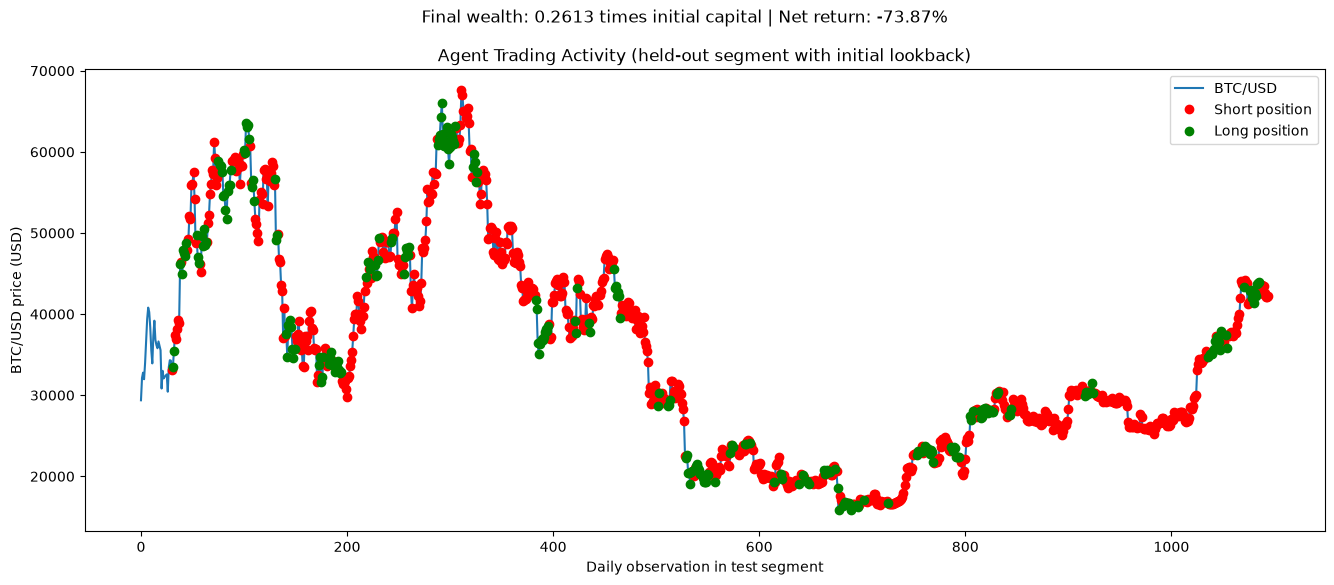

Behavior Analysis: Long exposure 24.9% of the test period.


In [8]:
print(f"Starting Validation on Future Data (2021+)...")

# 1. Setup Environment for Testing
# Evaluation starts after the test lookback, at the environment start tick.
agent.policy_net.eval()
state = env_test.reset(seed=SEED)
if isinstance(state, tuple): state = state[0]

done = False
total_reward = 0
action_list = []

while not done:
    # 2. Select Action (Pure Exploitation, No Randomness)
    # We pass epsilon=0.0 to force the agent to use the network
    action = agent.select_action(state, epsilon=0.0)
    action_list.append(action)
    
    # 3. Step
    step_result = env_test.step(action)
    
    # Robust Unpacking
    if len(step_result) == 5:
        state, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        state, reward, done, info = step_result
        
    total_reward += reward

# 4. Results Analysis
strategy_growth = env_test.unwrapped._total_profit
strategy_return = strategy_growth - 1.0
assert np.isclose(np.exp(total_reward), strategy_growth)
wealth = np.r_[1.0, env_test.history['total_profit']]
strategy_drawdown = np.min(wealth / np.maximum.accumulate(wealth) - 1.0)
print(f"Maximum strategy drawdown: {strategy_drawdown:.2%}")
print(f"Validation Complete.")
print(f"--------------------------------")
print(f"Strategy net return: {strategy_return:.2%}")
print(f"Cumulative log reward: {total_reward:.4f}")
print(f"--------------------------------")

# 5. Visualization using Gym-Anytrading's built-in renderer
plt.figure(figsize=(16, 6))
plt.cla()
env_test.render_all()
plt.title("Agent Trading Activity (held-out segment with initial lookback)")
plt.suptitle(f"Final wealth: {strategy_growth:.4f} times initial capital | Net return: {strategy_return:.2%}")
plt.xlabel("Daily observation in test segment")
plt.ylabel("BTC/USD price (USD)")
plt.legend(["BTC/USD", "Short position", "Long position"])
plt.show()

# 6. Exposure Distribution
positions = env_test.unwrapped._position_history[env_test.unwrapped._start_tick + 1:]
long_exposure = np.mean([position == Positions.Long for position in positions])
print(f"Behavior Analysis: Long exposure {long_exposure:.1%} of the test period.")

## 9. Comparable accounting

Compare DQN and buy-and-hold over exactly the same price interval, with the same entry and liquidation fee. Returns are dimensionless wealth changes, not dollar profits. The short side is a simplified daily exposure model; omitted market frictions can materially change results.


In [9]:
# Compare the same tradable interval, including entry and final liquidation costs.
initial_price = env_test.prices[env_test._start_tick]
final_price = env_test.prices[-1]
fee = env_test.trade_fee_percent
buy_and_hold_return = final_price / initial_price * (1 - fee) ** 2 - 1
start_date = test_df.index[env_test._start_tick].date()
end_date = test_df.index[-1].date()
print(f"Evaluation interval: {start_date} to {end_date}")
print(f"DQN toy-environment net return: {strategy_return:.2%}")
print(f"Buy-and-hold with the same entry/exit fee: {buy_and_hold_return:.2%}")
print(f"Return difference: {(strategy_return - buy_and_hold_return) * 100:.2f} percentage points")
bh_wealth = np.r_[1.0, env_test.prices[env_test._start_tick + 1:] / initial_price * (1 - fee)]
bh_wealth[-1] *= 1 - fee
bh_drawdown = np.min(bh_wealth / np.maximum.accumulate(bh_wealth) - 1)
print(f"Maximum drawdown: DQN {strategy_drawdown:.2%}; buy-and-hold {bh_drawdown:.2%}")


Evaluation interval: 2021-01-31 to 2023-12-31
DQN toy-environment net return: -73.87%
Buy-and-hold with the same entry/exit fee: 27.38%
Return difference: -101.25 percentage points
Maximum drawdown: DQN -84.08%; buy-and-hold -76.63%


## 10. Conclusion

The computed results above describe one DQN policy in a simplified, chronologically split BTC/USD environment. Reward and wealth share the same net-return definition, observations use training-only scaling, and the passive comparison uses matching dates and endpoint fees.

No claim of alpha, regime adaptation or deployable profitability follows from one split. Independent walk-forward periods, repeated seeds, realistic execution and financing costs, calibration of risk assumptions and stronger baselines would be required for such claims.
